In [1]:

import sys; sys.path.insert(0, "..")
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("../results/task3_judged.csv")
with open("../results/task3_metrics.json") as f:
    metrics = json.load(f)

judged = df[df["faithfulness"].notna()].copy()
for dim in ["faithfulness", "actionability", "tone"]:
    judged[dim] = judged[dim].astype(float)
judged["avg_score"] = judged[["faithfulness","actionability","tone"]].mean(axis=1)

print(f"Total: {len(df)}  |  Judged: {len(judged)}")
print(judged[["faithfulness","actionability","tone"]].describe().round(3))

Total: 50  |  Judged: 50
       faithfulness  actionability   tone
count        50.000         50.000  50.00
mean          4.160          4.540   4.94
std           1.057          0.838   0.24
min           1.000          3.000   4.00
25%           3.000          5.000   5.00
50%           5.000          5.000   5.00
75%           5.000          5.000   5.00
max           5.000          5.000   5.00


### Cell 2 — Score distributions per dimension

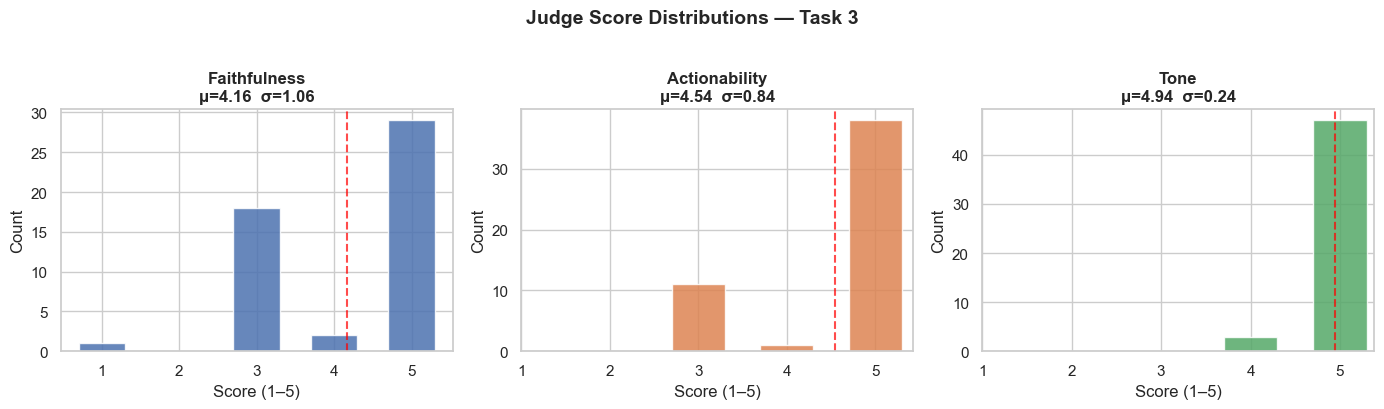

In [2]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
dims   = ["faithfulness", "actionability", "tone"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, dim, color in zip(axes, dims, colors):
    counts = judged[dim].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor="white", width=0.6)
    mean_v = judged[dim].mean()
    std_v  = judged[dim].std()
    ax.axvline(mean_v, color="red", linestyle="--", alpha=0.7)
    ax.set_title(f"{dim.capitalize()}\nμ={mean_v:.2f}  σ={std_v:.2f}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3, 4, 5])

plt.suptitle("Judge Score Distributions — Task 3", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/task3_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

###  Quality by star class (heatmap)
#### Key question: does response quality degrade for negative reviews (1-2 star)?
#### Expected: actionability lowest for 1 star(damage control is harder to be specific about)

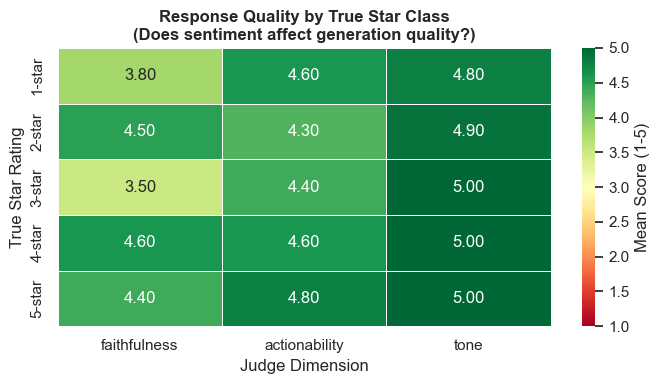

In [4]:


star_data = pd.DataFrame(metrics["quality_by_star_class"]).T.astype(float)
star_data.index = [f"{i}-star" for i in star_data.index]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(star_data, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=1, vmax=5, ax=ax, linewidths=0.5,
            cbar_kws={"label": "Mean Score (1-5)"})
ax.set_title("Response Quality by True Star Class\n(Does sentiment affect generation quality?)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Judge Dimension")
ax.set_ylabel("True Star Rating")
plt.tight_layout()
plt.savefig("../results/task3_quality_by_star.png", dpi=150)
plt.show()

### Cell 4 — Verdict distribution

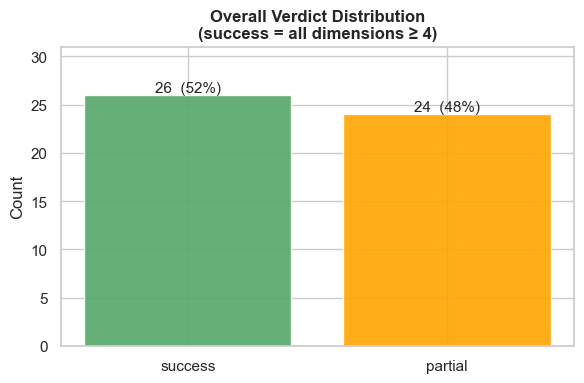

In [5]:

verdicts = judged["overall_verdict"].value_counts()
color_map = {"success": "#55A868", "partial": "#FFA500", "failure": "#C44E52"}
colors_v  = [color_map.get(v, "gray") for v in verdicts.index]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(verdicts.index, verdicts.values, color=colors_v, edgecolor="white", alpha=0.9)
for bar, val in zip(bars, verdicts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val}  ({val/len(judged):.0%})", ha="center", fontsize=11)
ax.set_title("Overall Verdict Distribution\n(success = all dimensions ≥ 4)", fontsize=12, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, max(verdicts.values) + 5)
plt.tight_layout()
plt.savefig("../results/task3_verdict_distribution.png", dpi=150)
plt.show()

###  Dimension correlations
#### faithfulness -> actionability should be strong positive 
#### if key_point is wrong, business_response cannot be specific

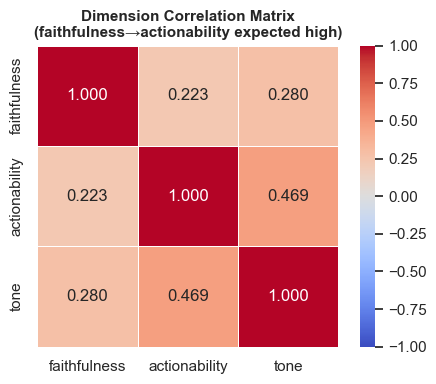


Interpretation:
  F↔A: 0.223  — extraction quality gates response specificity
  A↔T: 0.469  — specific responses tend to also feel warmer
  F↔T: 0.280  — weakest expected: tone is somewhat independent


In [6]:

dims = ["faithfulness", "actionability", "tone"]
corr_matrix = judged[dims].corr()

fig, ax = plt.subplots(figsize=(5, 4))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax,
            square=True, linewidths=0.5)
ax.set_title("Dimension Correlation Matrix\n(faithfulness→actionability expected high)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/task3_dimension_correlations.png", dpi=150)
plt.show()

print("\nInterpretation:")
print(f"  F↔A: {corr_matrix.loc['faithfulness','actionability']:.3f}  — extraction quality gates response specificity")
print(f"  A↔T: {corr_matrix.loc['actionability','tone']:.3f}  — specific responses tend to also feel warmer")
print(f"  F↔T: {corr_matrix.loc['faithfulness','tone']:.3f}  — weakest expected: tone is somewhat independent")

### Cross-task summary (all 5 strategies in one table)

In [7]:

with open("../results/task1_metrics.json") as f: m1 = json.load(f)
with open("../results/task2_metrics.json") as f: m2 = json.load(f)
with open("../results/task3_metrics.json") as f: m3 = json.load(f)

summary = pd.DataFrame([
    {"Task": "T1: Zero-Shot",  "Accuracy": m1["zero_shot"]["accuracy"], "Macro-F1": m1["zero_shot"]["macro_f1"], "Compliance": "100.0%", "Key Finding": "Baseline — 90%+ errors off-by-one"},
    {"Task": "T1: Few-Shot",   "Accuracy": m1["few_shot"]["accuracy"],  "Macro-F1": m1["few_shot"]["macro_f1"],  "Compliance": "100.0%", "Key Finding": "Class-4 F1 +10pp vs zero-shot"},
    {"Task": "T2: Direct",     "Accuracy": m2["direct"]["accuracy"],    "Macro-F1": m2["direct"]["macro_f1"],    "Compliance": "100.0%", "Key Finding": "Best overall — concise prompts win"},
    {"Task": "T2: CoT",        "Accuracy": m2["cot"]["accuracy"],       "Macro-F1": m2["cot"]["macro_f1"],       "Compliance": "99.5%",  "Key Finding": "CoT hurts at 8B — 19.6% mismatch rate"},
    {"Task": "T3: Assistant",  "Accuracy": m3["star_accuracy"],         "Macro-F1": m3["star_macro_f1"],         "Compliance": f"{m3['generation_compliance']:.1%}", "Key Finding": "Multi-output; actionability hardest dim"},
])
print(summary.to_string(index=False))

         Task  Accuracy  Macro-F1 Compliance                             Key Finding
T1: Zero-Shot    0.6200    0.6006     100.0%       Baseline — 90%+ errors off-by-one
 T1: Few-Shot    0.6500    0.6390     100.0%           Class-4 F1 +10pp vs zero-shot
   T2: Direct    0.6650    0.6545     100.0%      Best overall — concise prompts win
      T2: CoT    0.6181    0.6090      99.5%   CoT hurts at 8B — 19.6% mismatch rate
T3: Assistant    0.6200    0.6164     100.0% Multi-output; actionability hardest dim
